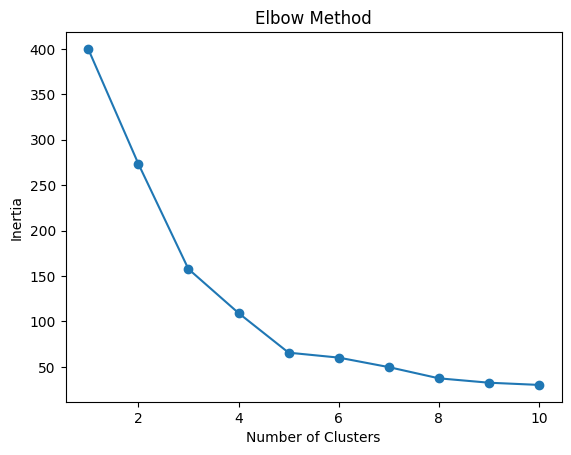

Silhouette Score: 0.5546571631111091


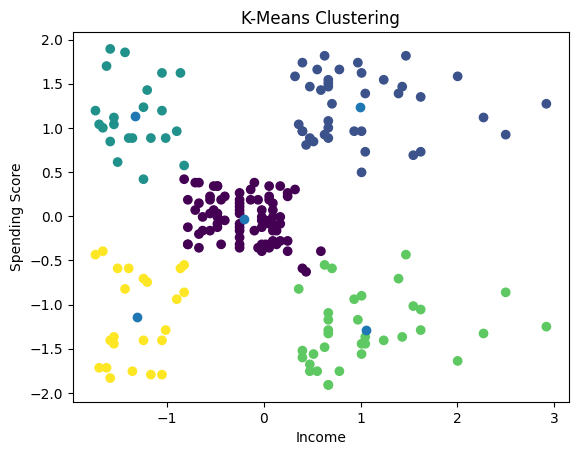

In [ ]:
#24BAD006
#Ajay Krishnan T

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")

features = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

inertia_vals = []
k_vals = range(1, 11)

for k in k_vals:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_data)
    inertia_vals.append(model.inertia_)

plt.plot(k_vals, inertia_vals, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(scaled_data)

df['Cluster'] = labels

sil_score = silhouette_score(scaled_data, labels)
print("Silhouette Score:", sil_score)

plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.show()

Silhouette Score: 0.5536892843811245


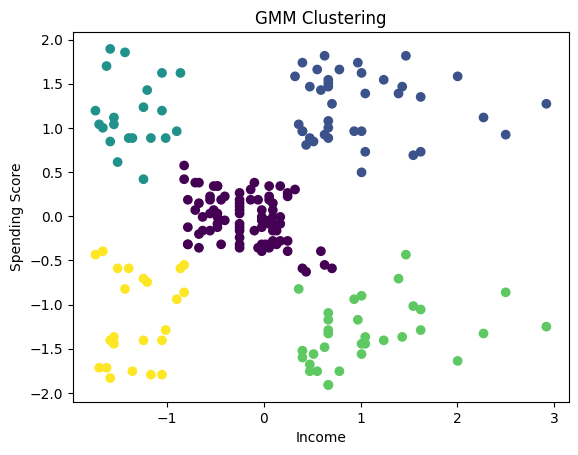

[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


In [ ]:
#24BAD006
#Ajay Krishnan T

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")

features = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(scaled_data)

labels = gmm.predict(scaled_data)
probs = gmm.predict_proba(scaled_data)

df['Cluster'] = labels

sil_score = silhouette_score(scaled_data, labels)
print("Silhouette Score:", sil_score)

plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=labels)
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("GMM Clustering")
plt.show()

print(probs[:5])